<a href="https://colab.research.google.com/github/Maryam-71295/Hesoftwares_Titanic_Analysis/blob/main/Hexsoftwares_Titanic_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O
import matplotlib.pyplot as plt # data visualization
import seaborn as sns

from sklearn.preprocessing import LabelEncoder # encoding categorical values
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import train_test_split # Splitting the dataset

from sklearn.ensemble import RandomForestClassifier # This is the model we will be using today, more about it later
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix # To be used for model evaluation

import warnings # We like doing dangerous stuff, we don't ignore warnings XD (But be careful in real life kids, listen to warnings! LOL)
warnings.filterwarnings('ignore')

In [2]:
# Importing the DataSet
train= pd.read_csv('/content/train.csv')
test= pd.read_csv('/content/test.csv')

In [3]:
train.head()
# Shows top 5 rows of the train dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test.head()
# Shows top 5 rows of the test dataset

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
train.info()
# provides information about the train dataset: Columns, number of non-missing values in each columns, and data type of each columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
train.describe().T
# Provides the statistical description of all the numerical columns

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [7]:
train.nunique()
# Gives the number of unique values in each class (column)

,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


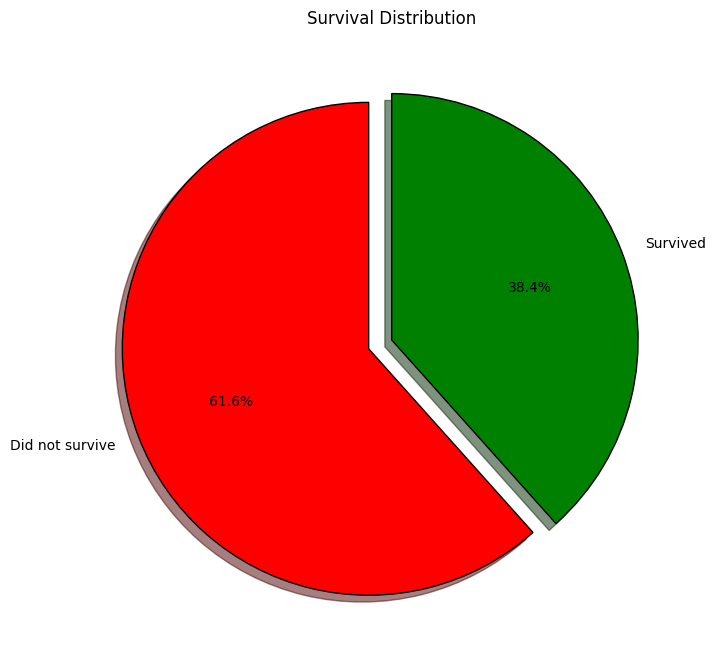

In [8]:
# Survival Distribution Pie chart

# Defining the exploding values
explode = (0.1, 0)  # "0.1" for the first slice (survived), "0" for the second slice (did not survive)

# Plotting the pie chart
train['Survived'].value_counts().plot.pie(
    autopct='%1.1f%%',
    labels=['Did not survive', 'Survived'],
    startangle=90,
    colors=['red', 'green'],
    explode=explode,  # Adding the explode effect
    shadow=True,  # Adding shadow for a 3D effect
    wedgeprops={'edgecolor': 'black'},  # Adding black borders to slices
    figsize=(8,8)  # Ensuring it's circular
)

# Adding a title
plt.title('Survival Distribution')

# Display the plot
plt.ylabel('')  # Hide the ylabel since it's redundant for a pie chart
plt.show()

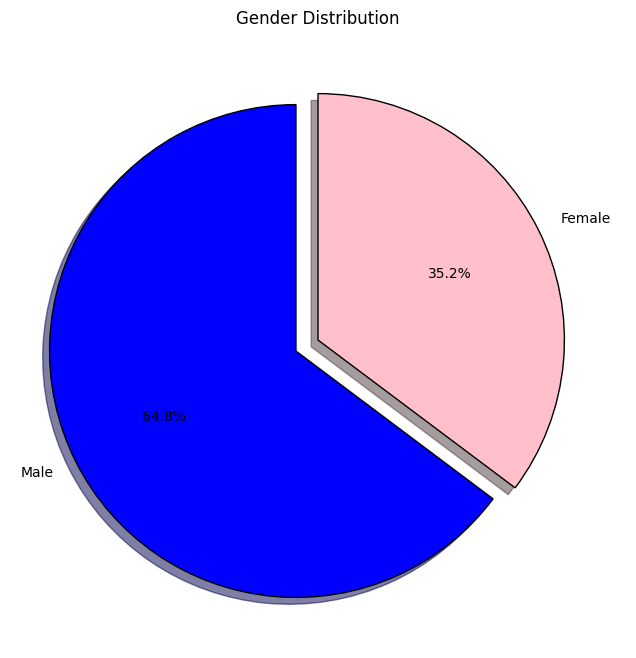

In [9]:
# 2. Gender Distribution (Sex column) - Pie chart
plt.figure(figsize=(8,8))
train['Sex'].value_counts().plot.pie(
    autopct='%1.1f%%',
    labels=['Male', 'Female'],
    startangle=90,
    colors=['blue', 'pink'],
    explode=(0.1, 0),  # Exploding the male slice for a visual effect
    shadow=True,
    wedgeprops={'edgecolor': 'black'},
    figsize=(8,8)
)
plt.title('Gender Distribution')
plt.ylabel('')  # Hide the ylabel since it's redundant for a pie chart
plt.show()

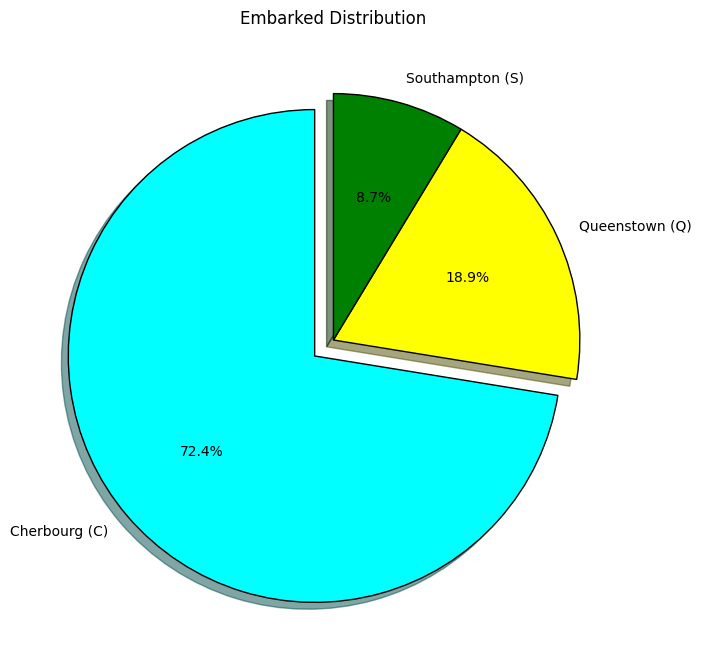

In [10]:
# 3. Embarked Distribution (Embarked column) - Pie chart
plt.figure(figsize=(8,8))
train['Embarked'].value_counts().plot.pie(
    autopct='%1.1f%%',
    labels=['Cherbourg (C)', 'Queenstown (Q)', 'Southampton (S)'],
    startangle=90,
    colors=['cyan', 'yellow', 'green'],
    explode=(0.1, 0, 0),  # Exploding the Cherbourg slice for emphasis
    shadow=True,
    wedgeprops={'edgecolor': 'black'},
    figsize=(8,8)
)
plt.title('Embarked Distribution')
plt.ylabel('')
plt.show()

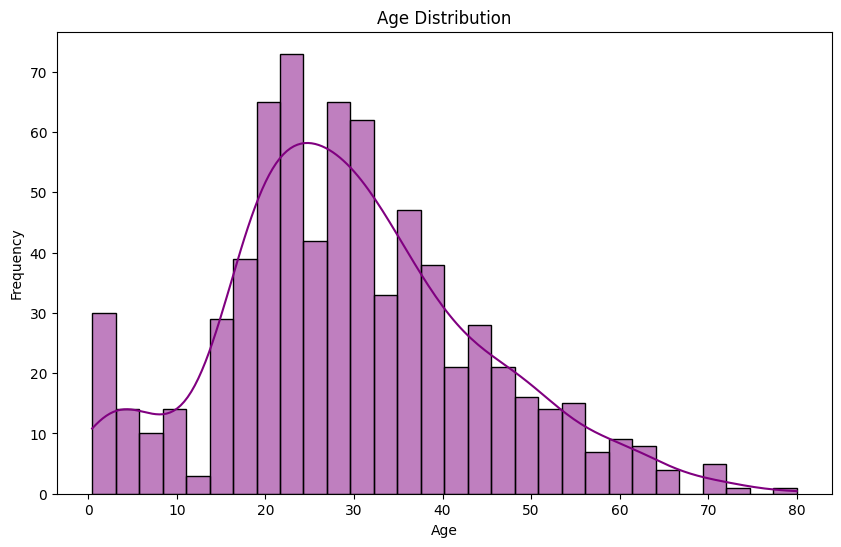

In [11]:
# 4. Age Distribution (Age column) - Histogram
plt.figure(figsize=(10,6))
sns.histplot(train['Age'].dropna(), bins=30, kde=True, color='purple')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

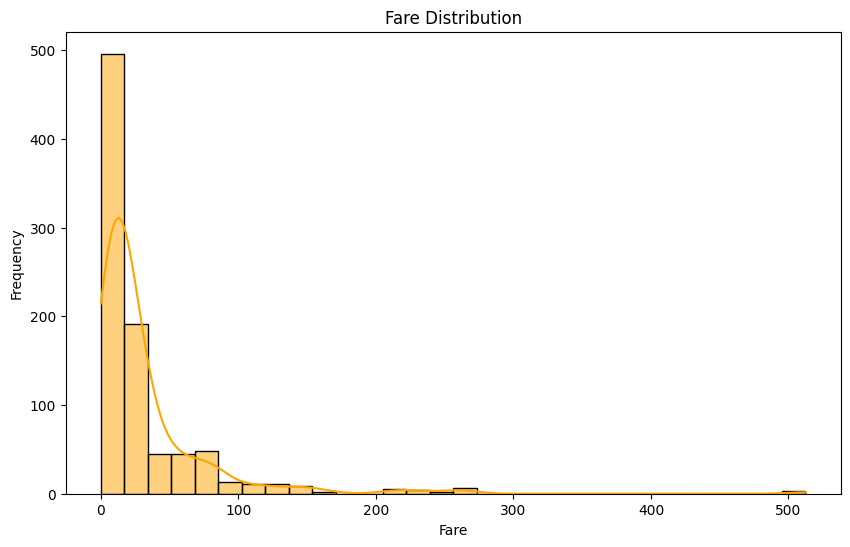

In [12]:
# 5. Fare Distribution (Fare column) - Histogram
plt.figure(figsize=(10,6))
sns.histplot(train['Fare'], bins=30, kde=True, color='orange')
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

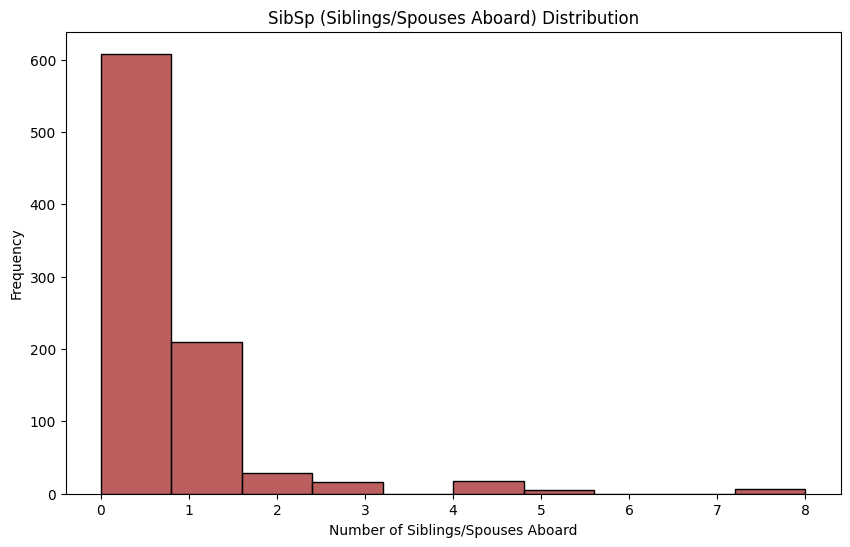

In [13]:
# 6. SibSp Distribution (Number of Siblings/Spouses Aboard) - Histogram
plt.figure(figsize=(10,6))
sns.histplot(train['SibSp'], bins=10, kde=False, color='brown')
plt.title('SibSp (Siblings/Spouses Aboard) Distribution')
plt.xlabel('Number of Siblings/Spouses Aboard')
plt.ylabel('Frequency')
plt.show()

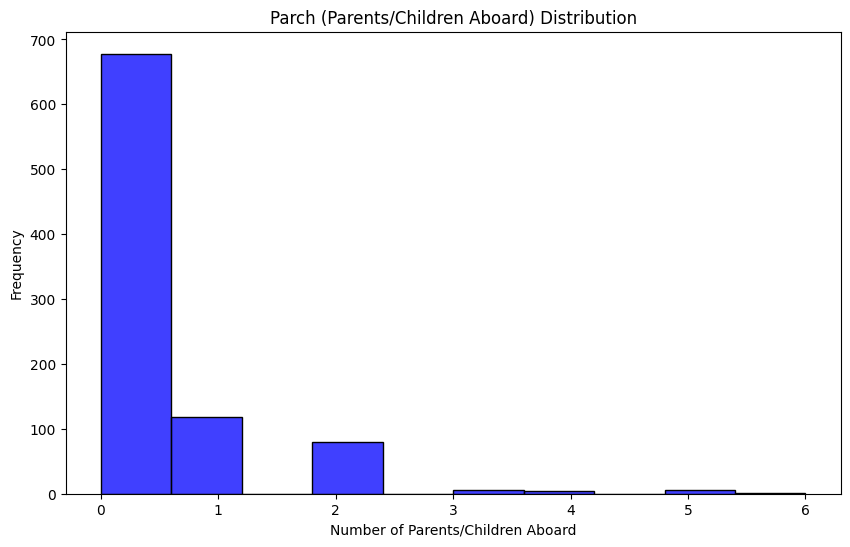

In [14]:
# 7. Parch Distribution (Number of Parents/Children Aboard) - Histogram
plt.figure(figsize=(10,6))
sns.histplot(train['Parch'], bins=10, kde=False, color='blue')
plt.title('Parch (Parents/Children Aboard) Distribution')
plt.xlabel('Number of Parents/Children Aboard')
plt.ylabel('Frequency')
plt.show()

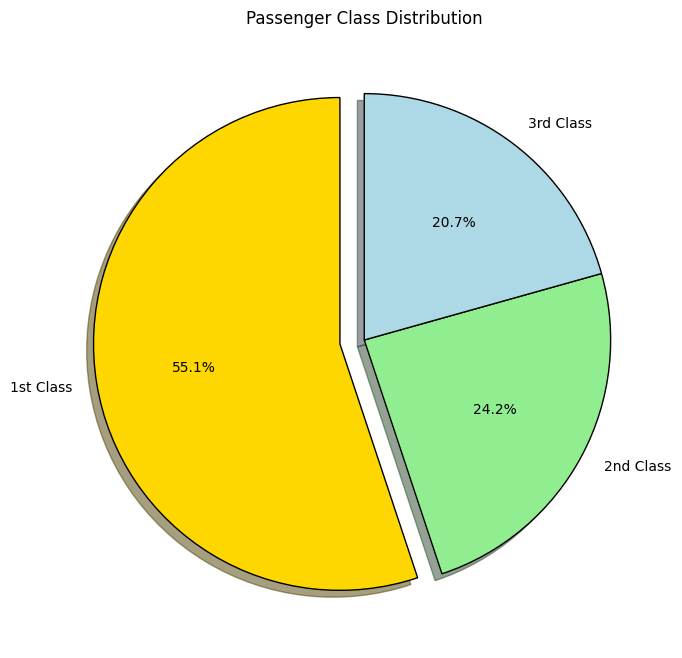

In [15]:
# 8. Passenger Class Distribution (Pclass) - Pie chart
plt.figure(figsize=(8,8))
train['Pclass'].value_counts().plot.pie(
    autopct='%1.1f%%',
    labels=['1st Class', '2nd Class', '3rd Class'],
    startangle=90,
    colors=['gold', 'lightgreen', 'lightblue'],
    explode=(0.1, 0, 0),  # Exploding the first class slice
    shadow=True,
    wedgeprops={'edgecolor': 'black'},
    figsize=(8,8)
)
plt.title('Passenger Class Distribution')
plt.ylabel('')
plt.show()

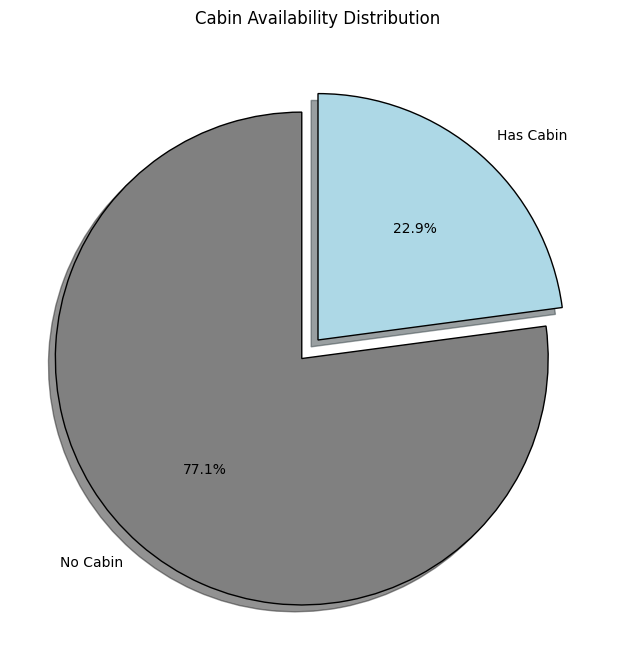

In [16]:
# 9. Cabin Distribution (Presence of Cabin) - Pie chart
plt.figure(figsize=(8,8))
train['Cabin'].notnull().value_counts().plot.pie(
    autopct='%1.1f%%',
    labels=['No Cabin', 'Has Cabin'],
    startangle=90,
    colors=['gray', 'lightblue'],
    explode=(0.1, 0),  # Exploding the 'Has Cabin' slice
    shadow=True,
    wedgeprops={'edgecolor': 'black'},
    figsize=(8,8)
)
plt.title('Cabin Availability Distribution')
plt.ylabel('')
plt.show()

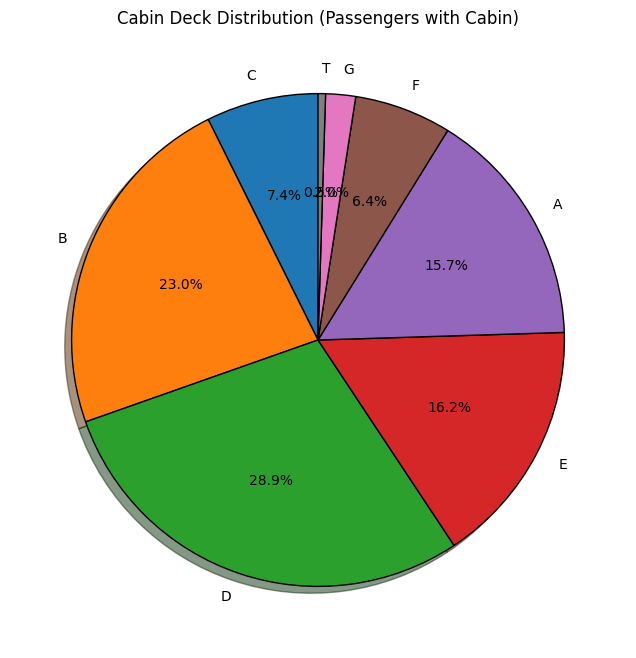

In [17]:
# 10. Cabin Category (Deck) Distribution for Passengers with Cabin

# We will extract the first letter of the 'Cabin' and visualize it
# Extract the deck (first letter of cabin) for passengers with a cabin
train['CabinDeck'] = train['Cabin'].str[0]  # Get the first letter (Deck)

# While we are at it, let's add 'CabinDeck' column on test data as well.
test['CabinDeck'] = test['Cabin'].str[0]

df_with_cabin = train[train['Cabin'].notnull()]  # Filter passengers who have a cabin

# Plot the distribution of cabins by deck (first letter)
plt.figure(figsize=(8,6))
df_with_cabin['CabinDeck'].value_counts().sort_index().plot.pie(
    autopct='%1.1f%%',
    labels=df_with_cabin['CabinDeck'].value_counts().index,
    startangle=90,
    shadow=True,
    wedgeprops={'edgecolor': 'black'},
    figsize=(8,8)
)
plt.title('Cabin Deck Distribution (Passengers with Cabin)')
plt.ylabel('')
plt.show()

In [18]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,CabinDeck
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,NaN
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,NaN
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,NaN


In [19]:
def drop(df):
    df.drop(columns=['PassengerId', 'Ticket', 'Cabin'], axis=1, inplace=True)

drop(train)
drop(test)

#Let's check if the columns are removed or not:
train.head(), test.head()

(   Survived  Pclass                                               Name  \
 0         0       3                            Braund, Mr. Owen Harris   
 1         1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...   
 2         1       3                             Heikkinen, Miss. Laina   
 3         1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)   
 4         0       3                           Allen, Mr. William Henry   
 
       Sex   Age  SibSp  Parch     Fare Embarked CabinDeck  
 0    male  22.0      1      0   7.2500        S       NaN  
 1  female  38.0      1      0  71.2833        C         C  
 2  female  26.0      0      0   7.9250        S       NaN  
 3  female  35.0      1      0  53.1000        S         C  
 4    male  35.0      0      0   8.0500        S       NaN  ,
    Pclass                                          Name     Sex   Age  SibSp  \
 0       3                              Kelly, Mr. James    male  34.5      0   
 1       3         

In [20]:
train.isnull().sum(), test.isnull().sum()

(Survived       0
 Pclass         0
 Name           0
 Sex            0
 Age          177
 SibSp          0
 Parch          0
 Fare           0
 Embarked       2
 CabinDeck    687
 dtype: int64,
 Pclass         0
 Name           0
 Sex            0
 Age           86
 SibSp          0
 Parch          0
 Fare           1
 Embarked       0
 CabinDeck    327
 dtype: int64)

In [21]:
def fill_empty(df):
    df['Age']= df['Age'].fillna(df.groupby(['Pclass', 'Sex'])['Age'].transform('median'))
    df['Embarked']=df['Embarked'].fillna('C')
    df['Fare']=df['Fare'].fillna(df['Fare'].median())
    df['CabinDeck']=df['CabinDeck'].fillna('N')

fill_empty(train)
fill_empty(test)

# Check for any remaining null values:
train.isnull().sum(), test.isnull().sum()

(Survived     0
 Pclass       0
 Name         0
 Sex          0
 Age          0
 SibSp        0
 Parch        0
 Fare         0
 Embarked     0
 CabinDeck    0
 dtype: int64,
 Pclass       0
 Name         0
 Sex          0
 Age          0
 SibSp        0
 Parch        0
 Fare         0
 Embarked     0
 CabinDeck    0
 dtype: int64)

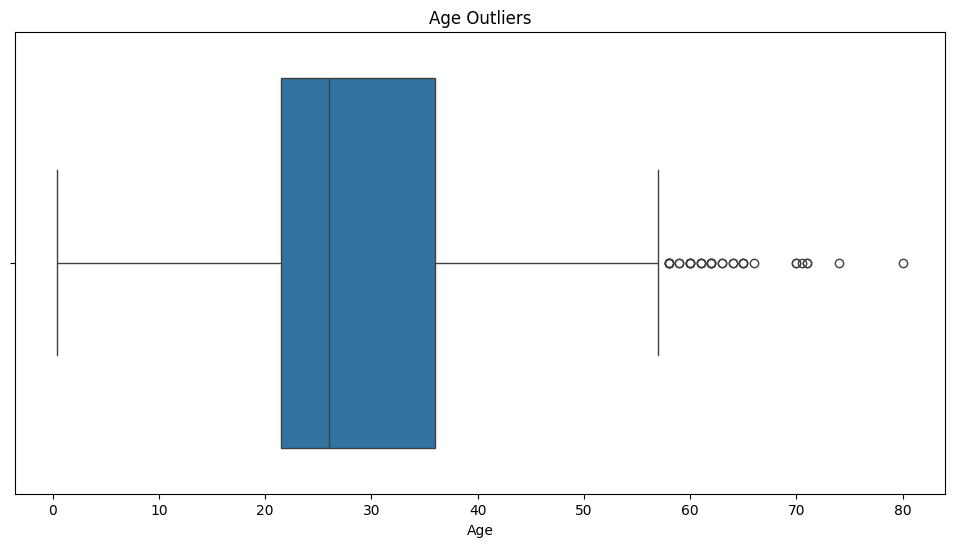

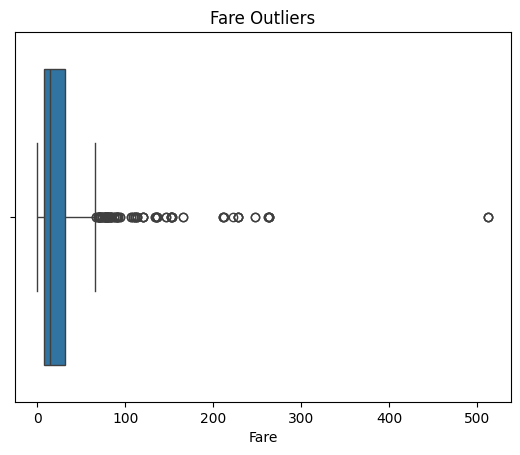

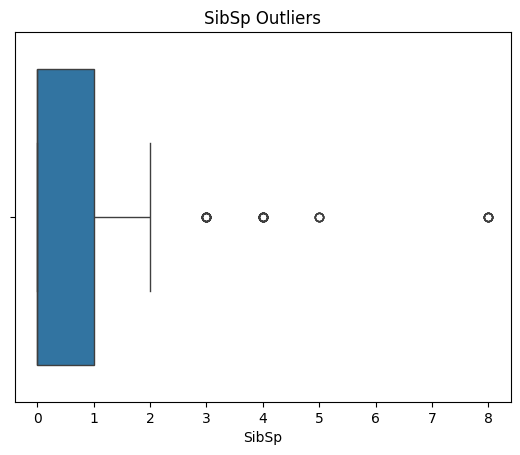

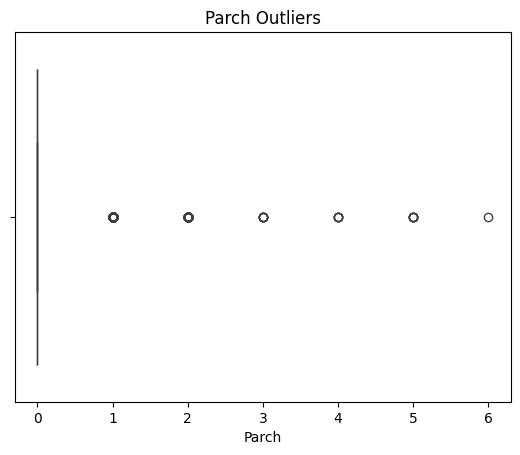

In [22]:
# Set up the figure size
plt.figure(figsize=(12,6))

# Box plots to detect outliers for numerical columns
sns.boxplot(x=train['Age'])
plt.title('Age Outliers')
plt.show()

sns.boxplot(x=train['Fare'])
plt.title('Fare Outliers')
plt.show()

sns.boxplot(x=train['SibSp'])
plt.title('SibSp Outliers')
plt.show()

sns.boxplot(x=train['Parch'])
plt.title('Parch Outliers')
plt.show()

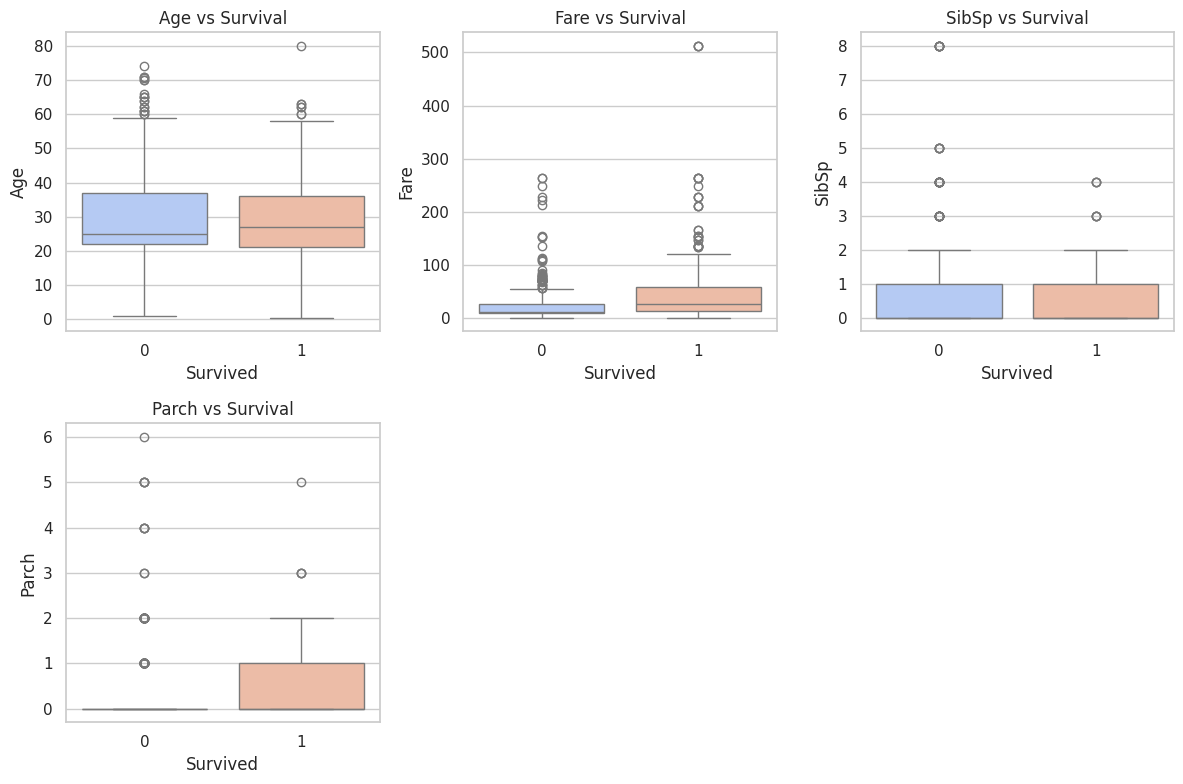

In [23]:
# Plotting Survival by Age, Fare, SibSp and Parch

sns.set(style="whitegrid")

# Set up the figure size
plt.figure(figsize=(12, 8))

# Plot: Age vs. Survival
plt.subplot(2, 3, 1)
sns.boxplot(x='Survived', y='Age', data=train, palette='coolwarm')
plt.title('Age vs Survival')

# Plot: Fare vs. Survival
plt.subplot(2, 3, 2)
sns.boxplot(x='Survived', y='Fare', data=train, palette='coolwarm')
plt.title('Fare vs Survival')

# Plot: SibSp vs. Survival
plt.subplot(2, 3, 3)
sns.boxplot(x='Survived', y='SibSp', data=train, palette='coolwarm')
plt.title('SibSp vs Survival')

# Plot: Parch vs. Survival
plt.subplot(2, 3, 4)
sns.boxplot(x='Survived', y='Parch', data=train, palette='coolwarm')
plt.title('Parch vs Survival')

# Adjust the layout
plt.tight_layout()
plt.show()

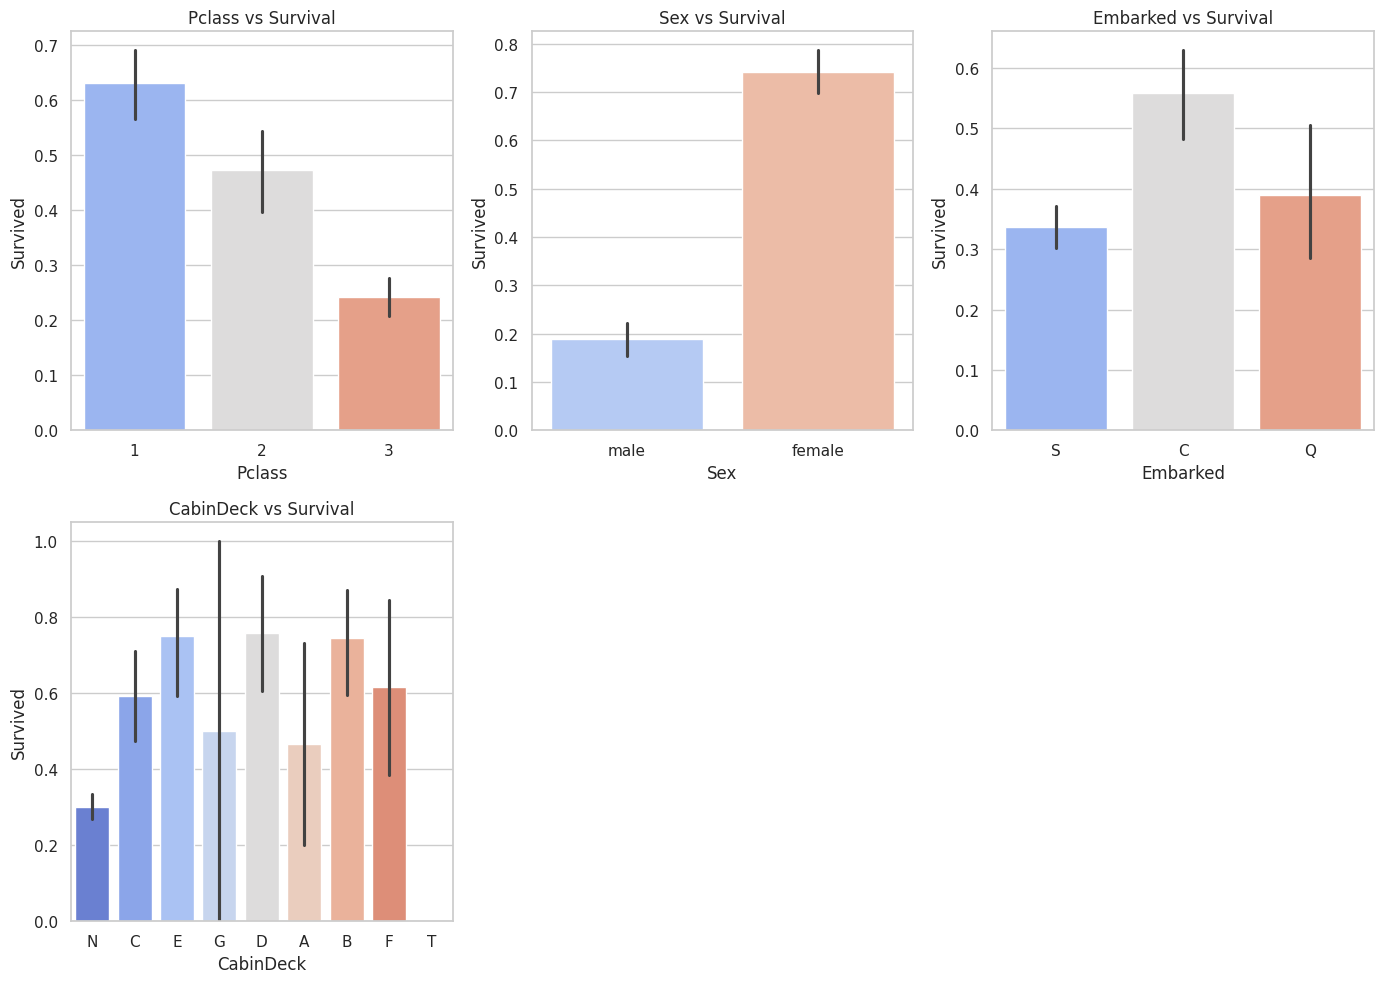

In [24]:
# Set up the figure size
plt.figure(figsize=(14, 10))

# Plot: Pclass vs. Survival (Barplot)
plt.subplot(2, 3, 1)
sns.barplot(x='Pclass', y='Survived', data=train, palette='coolwarm')
plt.title('Pclass vs Survival')

# Plot: Sex vs. Survival (Barplot)
plt.subplot(2, 3, 2)
sns.barplot(x='Sex', y='Survived', data=train, palette='coolwarm')
plt.title('Sex vs Survival')

# Plot: Embarked vs. Survival (Barplot)
plt.subplot(2, 3, 3)
sns.barplot(x='Embarked', y='Survived', data=train, palette='coolwarm')
plt.title('Embarked vs Survival')

# Plot: CabinDeck vs. Survival (Barplot)
plt.subplot(2, 3, 4)
sns.barplot(x='CabinDeck', y='Survived', data=train, palette='coolwarm')
plt.title('CabinDeck vs Survival')

# Adjust the layout
plt.tight_layout()
plt.show()

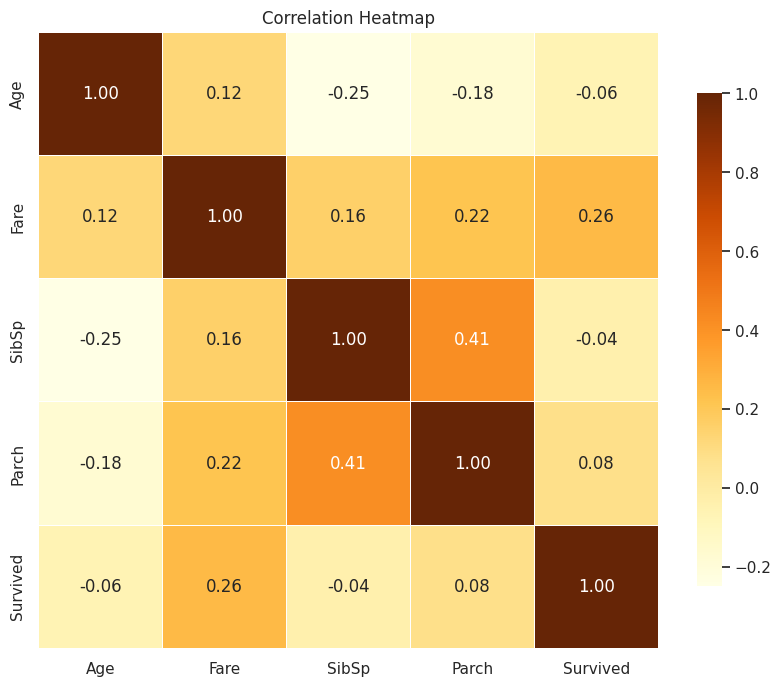

In [25]:
# Plot: Correlation Heatmap for numerical features
plt.figure(figsize=(10, 8))
corr_matrix = train[['Age', 'Fare', 'SibSp', 'Parch','Survived']].corr()  # Correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='YlOrBr', fmt='.2f', linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap')
plt.show()

In [26]:
def encode(df):
    # Label encode 'Sex' and 'Pclass' (binary and ordinal)
    label_encoder = LabelEncoder() # 1, 2, 3
    df['Sex']= label_encoder.fit_transform(df['Sex'])  # 0 for male, 1 for female
    df['Pclass'] = label_encoder.fit_transform(df['Pclass'])

# Label encoding train and test:
encode(train)
encode(test)

# One-hot encoding on train and test:
# One-hot encode 'Embarked', and 'CabinDeck' (nominal)
train = pd.get_dummies(train, columns=['Embarked', 'CabinDeck'], drop_first=True)
test = pd.get_dummies(test, columns=['Embarked', 'CabinDeck'], drop_first=True)



# Check the resulting columns
train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,CabinDeck_B,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_N,CabinDeck_T
0,0,2,"Braund, Mr. Owen Harris",1,22.0,1,0,7.2500,False,True,False,False,False,False,False,False,True,False
1,1,0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,71.2833,False,False,False,True,False,False,False,False,False,False
2,1,2,"Heikkinen, Miss. Laina",0,26.0,0,0,7.9250,False,True,False,False,False,False,False,False,True,False
3,1,0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,53.1000,False,True,False,True,False,False,False,False,False,False
4,0,2,"Allen, Mr. William Henry",1,35.0,0,0,8.0500,False,True,False,False,False,False,False,False,True,False


In [27]:
# Creating a map for titles:
titles={
        'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Dr': 4, 'Rev': 5,
        'Col': 6, 'Major': 7, 'Mlle': 8, 'Ms': 9, 'Lady': 10, 'Countess': 11,
        'Jonkheer': 12, 'Dona': 13, 'Sir': 14, 'Capt': 15, 'Mme': 16, 'Don': 17
}

def feature_engg(df):
    # Family Size:
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 for the passenger itself

    # Title:
    df['Title'] = df['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())
    df['Title'] = df['Title'].map(titles).fillna(-1)  # Assigning -1 for unknown titles

    # Drop Name column:
    df.drop('Name', axis=1, inplace=True)

# Applying Feature Engineering:
feature_engg(train)
feature_engg(test)

In [28]:
# Check the datasets now

train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,CabinDeck_B,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_N,CabinDeck_T,FamilySize,Title
0,0,2,1,22.0,1,0,7.2500,False,True,False,False,False,False,False,False,True,False,2,0.0
1,1,0,0,38.0,1,0,71.2833,False,False,False,True,False,False,False,False,False,False,2,2.0
2,1,2,0,26.0,0,0,7.9250,False,True,False,False,False,False,False,False,True,False,1,1.0
3,1,0,0,35.0,1,0,53.1000,False,True,False,True,False,False,False,False,False,False,2,2.0
4,0,2,1,35.0,0,0,8.0500,False,True,False,False,False,False,False,False,True,False,1,0.0


In [29]:
# Features (X) and Target (y)
X = train.drop('Survived', axis=1)  # Dropping irrelevant column
y = train['Survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Test_size=0.2: test set will have 20% of data

# Check the shapes
X_train.shape, X_test.shape

((712, 18), (179, 18))

In [30]:
# Create a Random Forest Classifier model
rf_model = RandomForestClassifier(n_estimators=200, max_depth = 6, random_state=42)

# Train the model on the training data
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=6, n_estimators=200, random_state=42)

In [31]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test)

y_pred

array([1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1])

In [32]:
# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8380

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.86       105
           1       0.82      0.78      0.80        74

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179


Confusion Matrix:
[[92 13]
 [16 58]]


In [33]:
'''

# Although we are skipping this, but you can try hyperparameter tuning yourself to see how it affects the accuracy!
# This sample code might be a good starting point:

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define parameter distributions
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['auto', 'sqrt', 'log2'],
    'bootstrap': [True, False]
}

# Perform RandomizedSearchCV
random_search = RandomizedSearchCV(rf_model, param_distributions=param_dist,
                                   n_iter=100, cv=5, n_jobs=-1, verbose=2)
random_search.fit(X_train, y_train)

# Get the best model
best_rf_model = random_search.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test)

# Evaluate the tuned model
accuracy_random = accuracy_score(y_test, y_pred_tuned)
print(f"Accuracy (Random Search): {accuracy_random:.4f}")

'''

'\n\n# Although we are skipping this, but you can try hyperparameter tuning yourself to see how it affects the accuracy!\n# This sample code might be a good starting point:\n\nfrom sklearn.model_selection import RandomizedSearchCV\nfrom scipy.stats import randint\n\n# Define parameter distributions\nparam_dist = {\n    \'n_estimators\': randint(50, 200),\n    \'max_depth\': [None, 10, 20, 30, 40, 50],\n    \'min_samples_split\': randint(2, 10),\n    \'min_samples_leaf\': randint(1, 10),\n    \'max_features\': [\'auto\', \'sqrt\', \'log2\'],\n    \'bootstrap\': [True, False]\n}\n\n# Perform RandomizedSearchCV\nrandom_search = RandomizedSearchCV(rf_model, param_distributions=param_dist, \n                                   n_iter=100, cv=5, n_jobs=-1, verbose=2)\nrandom_search.fit(X_train, y_train)\n\n# Get the best model\nbest_rf_model = random_search.best_estimator_\ny_pred_tuned = best_rf_model.predict(X_test)\n\n# Evaluate the tuned model\naccuracy_random = accuracy_score(y_test, y_p

In [34]:
# # Detailed classification report
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred_tuned))

# # Confusion matrix
# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, y_pred_tuned))

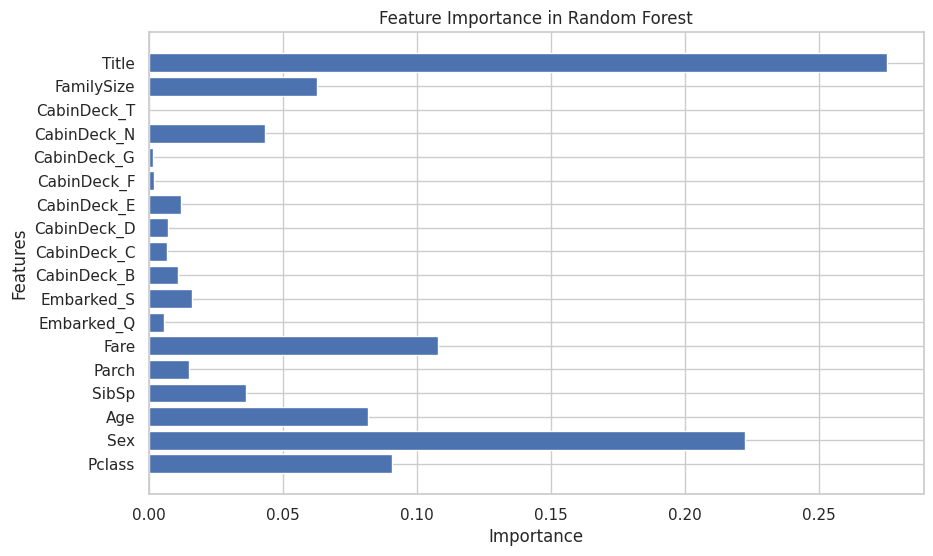

In [35]:
# Get feature importance from the trained model
feature_importance = rf_model.feature_importances_

# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(X_train.columns, feature_importance)
plt.title("Feature Importance in Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

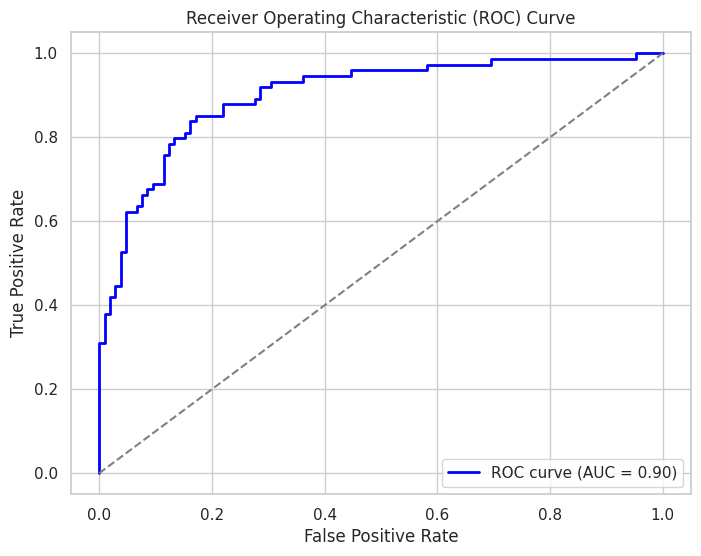

In [36]:
from sklearn.metrics import roc_curve, auc

# Get the false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, rf_model.predict_proba(X_test)[:, 1])

# Compute the area under the curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # diagonal line (random classifier)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

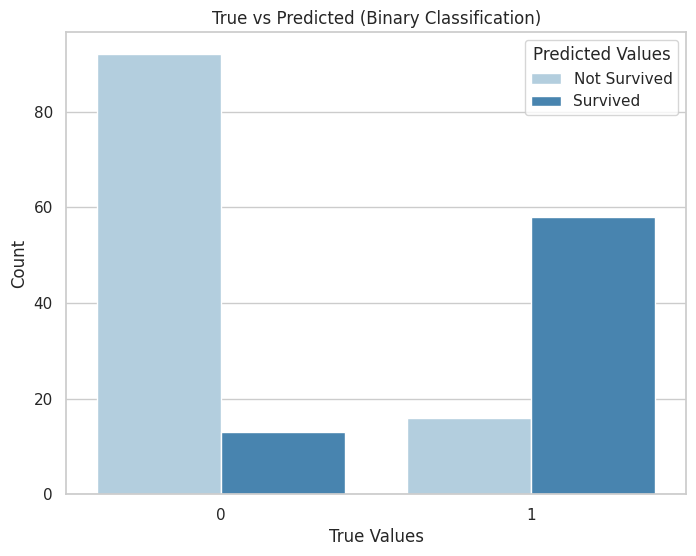

In [37]:
# Countplot of true vs predicted

# Create a comparison DataFrame to easily visualize True vs Predicted values
df_comparison = pd.DataFrame({'True': y_test, 'Predicted': y_pred})

# Plot True vs Predicted using a countplot
plt.figure(figsize=(8, 6))
sns.countplot(data=df_comparison, x='True', hue='Predicted', palette='Blues')
plt.title("True vs Predicted (Binary Classification)")
plt.xlabel('True Values')
plt.ylabel('Count')
plt.legend(title='Predicted Values', loc='upper right', labels=['Not Survived', 'Survived'])
plt.show()